In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries are installed!")

All libraries are installed!


In [2]:
data = pd.read_csv("../dataset/Salary Data.csv")
print(data.shape)

(375, 6)


In [3]:
print(data.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [4]:
data = data.dropna()

In [5]:
print(data.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [6]:
print(data.duplicated().sum())

49


In [7]:
data = data.drop_duplicates()

In [8]:
print(data.duplicated().sum())
print(data.shape)

0
(324, 6)


In [9]:
print(data.info())

<class 'pandas.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  324 non-null    float64
 1   Gender               324 non-null    str    
 2   Education Level      324 non-null    str    
 3   Job Title            324 non-null    str    
 4   Years of Experience  324 non-null    float64
 5   Salary               324 non-null    float64
dtypes: float64(3), str(3)
memory usage: 29.0 KB
None


In [10]:
data['Age'] = pd.to_numeric(data['Age'])
data['Years of Experience'] = pd.to_numeric(data['Years of Experience'])
data['Salary'] = pd.to_numeric(data['Salary'])

In [11]:
print(data)

      Age  Gender Education Level                            Job Title  \
0    32.0    Male      Bachelor's                    Software Engineer   
1    28.0  Female        Master's                         Data Analyst   
2    45.0    Male             PhD                       Senior Manager   
3    36.0  Female      Bachelor's                      Sales Associate   
4    52.0    Male        Master's                             Director   
..    ...     ...             ...                                  ...   
348  28.0  Female      Bachelor's            Junior Operations Manager   
349  36.0    Male      Bachelor's  Senior Business Development Manager   
350  44.0  Female             PhD                Senior Data Scientist   
351  31.0    Male      Bachelor's         Junior Marketing Coordinator   
371  43.0    Male        Master's               Director of Operations   

     Years of Experience    Salary  
0                    5.0   90000.0  
1                    3.0   65000.0  


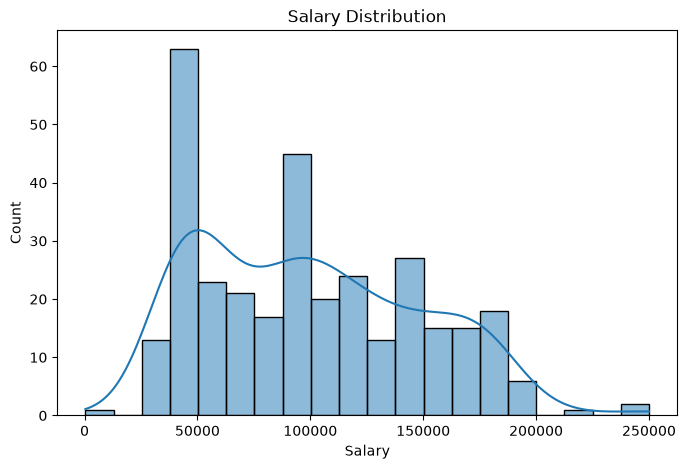

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data['Salary'], bins=20, kde=True)
plt.title("Salary Distribution")
plt.show()

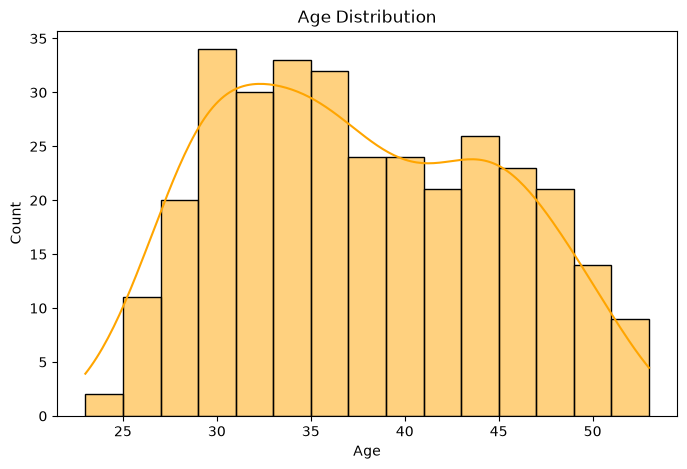

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=15, kde=True, color='orange')
plt.title("Age Distribution")
plt.show()

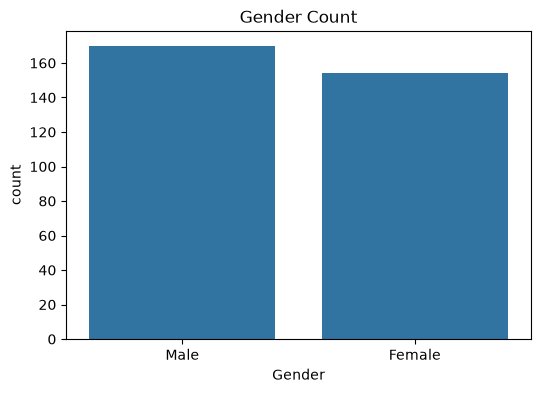

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=data)
plt.title("Gender Count")
plt.show()

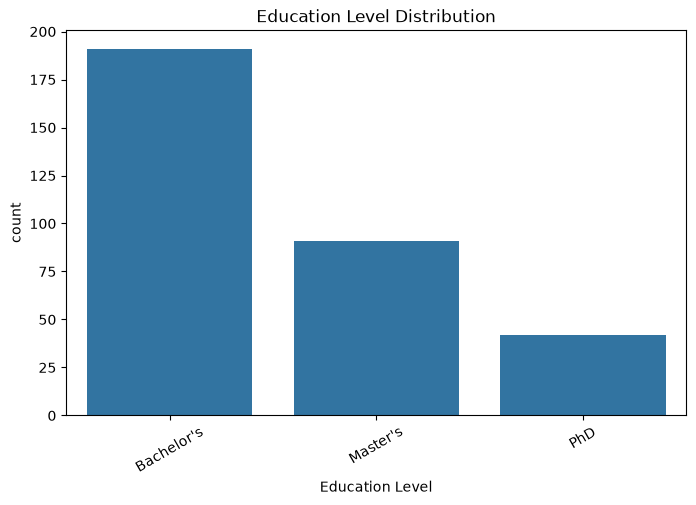

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Education Level', data=data)
plt.title("Education Level Distribution")
plt.xticks(rotation=30)
plt.show()

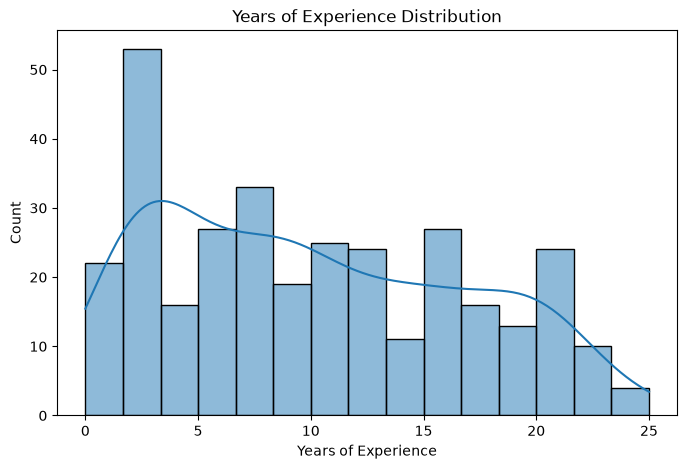

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data['Years of Experience'], bins=15, kde=True)
plt.title("Years of Experience Distribution")
plt.show()

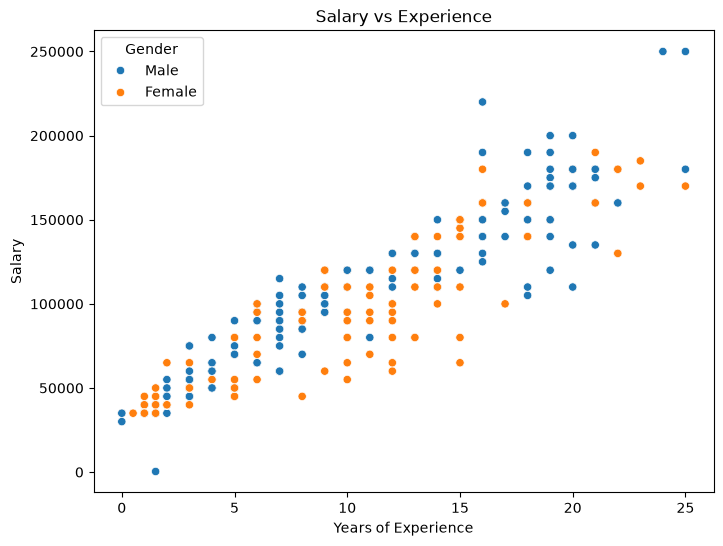

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Years of Experience',
    y='Salary',
    hue='Gender',
    data=data
)

plt.title("Salary vs Experience")
plt.show()

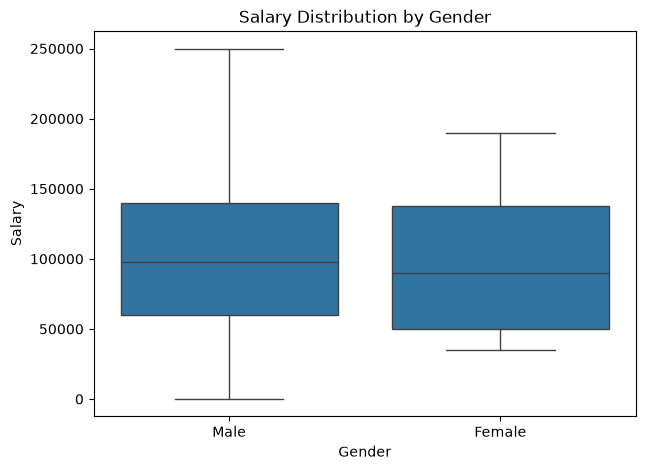

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='Gender',
    y='Salary',
    data=data
)

plt.title("Salary Distribution by Gender")
plt.show()

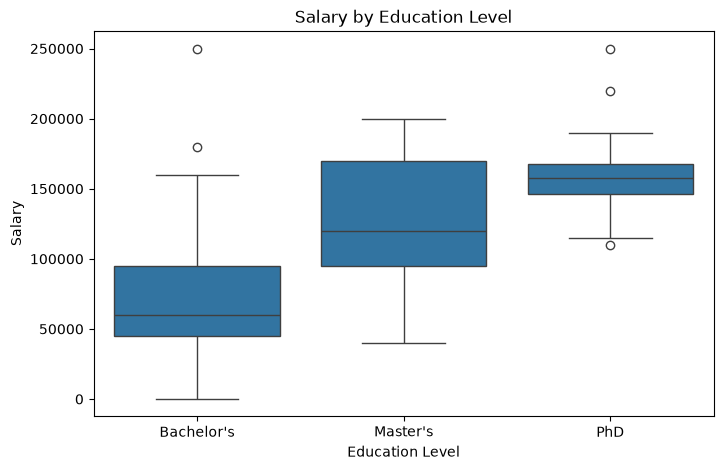

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Education Level',
    y='Salary',
    data=data
)

plt.title("Salary by Education Level")
plt.show()

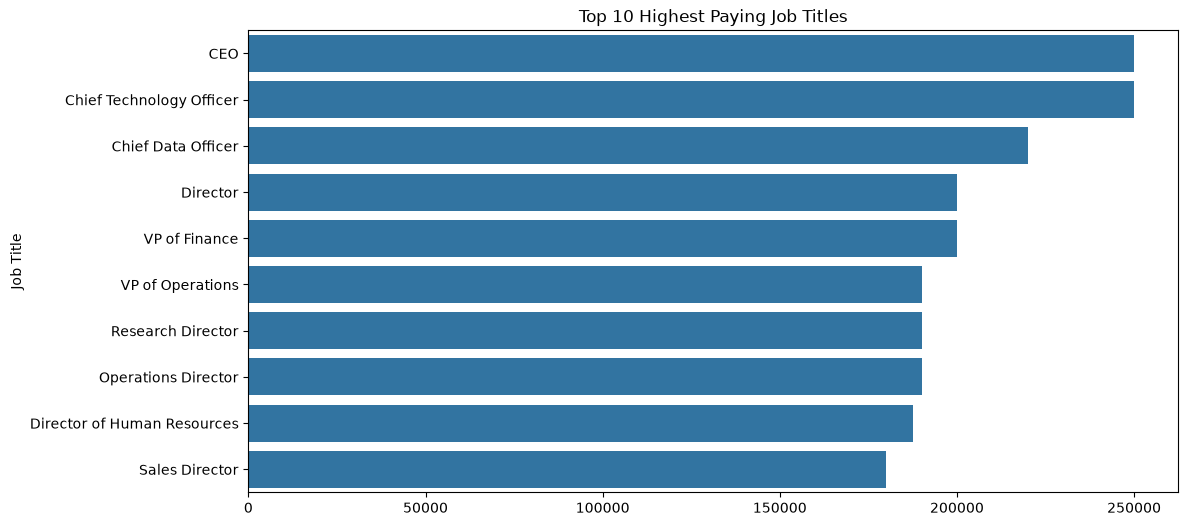

In [20]:
top_jobs = (
    data.groupby('Job Title')['Salary']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 10 Highest Paying Job Titles")
plt.show()

Job Title
CEO                                250000.0
Chief Technology Officer           250000.0
Chief Data Officer                 220000.0
Director                           200000.0
VP of Finance                      200000.0
VP of Operations                   190000.0
Research Director                  190000.0
Operations Director                190000.0
Director of Human Resources        187500.0
Sales Director                     180000.0
Human Resources Director           180000.0
Director of Sales and Marketing    180000.0
Director of Human Capital          180000.0
Director of HR                     180000.0
Director of Engineering            180000.0
Name: Salary, dtype: float64


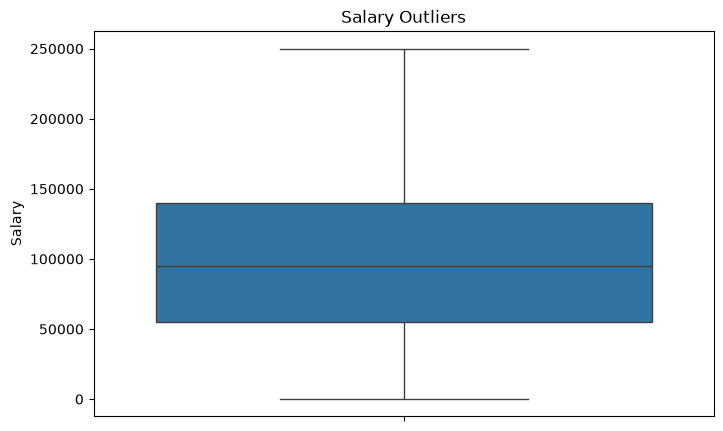

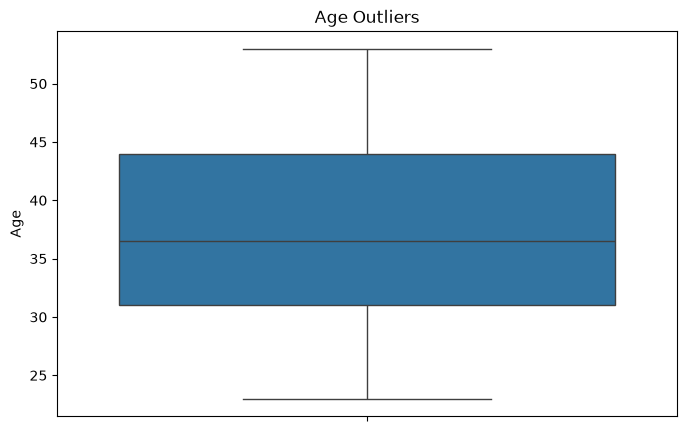

In [25]:
job_salary = (
    data.groupby('Job Title')['Salary']
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

print(job_salary)

plt.figure(figsize=(8,5))
sns.boxplot(y=data['Salary'])
plt.title("Salary Outliers")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=data['Age'])
plt.title("Age Outliers")
plt.show()

In [26]:
numerical_df = data[
    ['Age',
     'Years of Experience',
     'Salary']
]

                          Age  Years of Experience    Salary
Age                  1.000000             0.979192  0.916543
Years of Experience  0.979192             1.000000  0.924455
Salary               0.916543             0.924455  1.000000


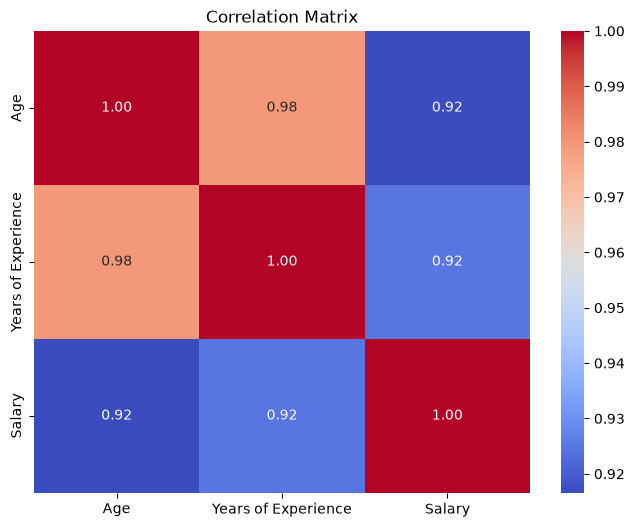

In [28]:
corr_matrix = numerical_df.corr()

print(corr_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

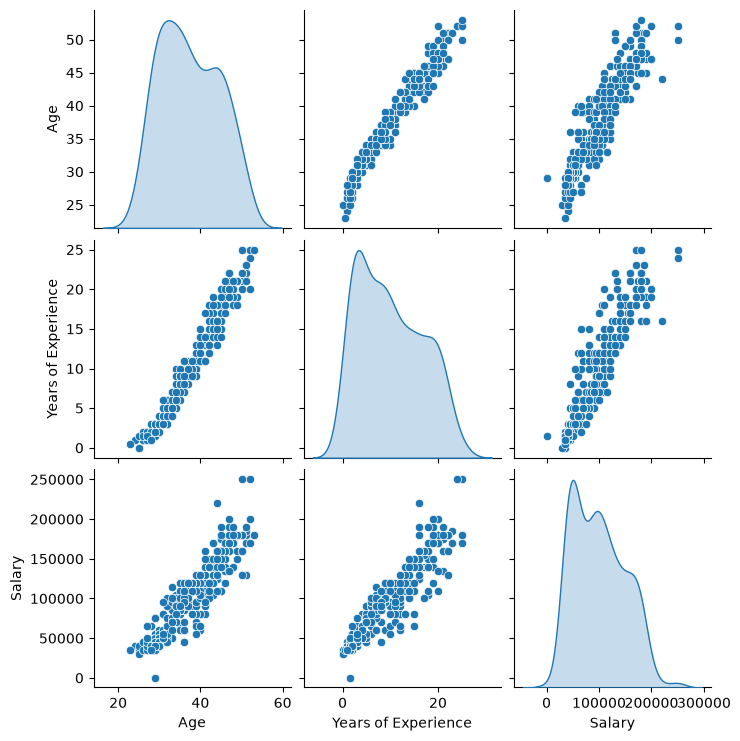

In [29]:
sns.pairplot(
    numerical_df,
    diag_kind='kde'
)

plt.show()

In [31]:
data.to_csv("../dataset/clean_data.csv", index=False)